In [2]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [4]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [30]:
def train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs,
	clip_grad_norm=None
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			if clip_grad_norm is not None:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

Epoch: 1/30, Loss: 0.53, Train Metric: 0.515, Valid Metric: 0.453
Epoch: 2/30, Loss: 0.384, Train Metric: 0.444, Valid Metric: 0.443
Epoch: 3/30, Loss: 0.362, Train Metric: 0.426, Valid Metric: 0.426
Epoch: 4/30, Loss: 0.347, Train Metric: 0.413, Valid Metric: 0.414
Epoch: 5/30, Loss: 0.339, Train Metric: 0.407, Valid Metric: 0.421
Epoch: 6/30, Loss: 0.327, Train Metric: 0.398, Valid Metric: 0.391
Epoch: 7/30, Loss: 0.314, Train Metric: 0.388, Valid Metric: 0.388
Epoch: 8/30, Loss: 0.311, Train Metric: 0.386, Valid Metric: 0.39
Epoch: 9/30, Loss: 0.313, Train Metric: 0.385, Valid Metric: 0.412
Epoch: 10/30, Loss: 0.303, Train Metric: 0.38, Valid Metric: 0.445
Epoch: 11/30, Loss: 0.301, Train Metric: 0.379, Valid Metric: 0.376
Epoch: 12/30, Loss: 0.293, Train Metric: 0.373, Valid Metric: 0.371
Epoch: 13/30, Loss: 0.293, Train Metric: 0.372, Valid Metric: 0.392
Epoch: 14/30, Loss: 0.294, Train Metric: 0.372, Valid Metric: 0.386
Epoch: 15/30, Loss: 0.291, Train Metric: 0.37, Valid Metric:

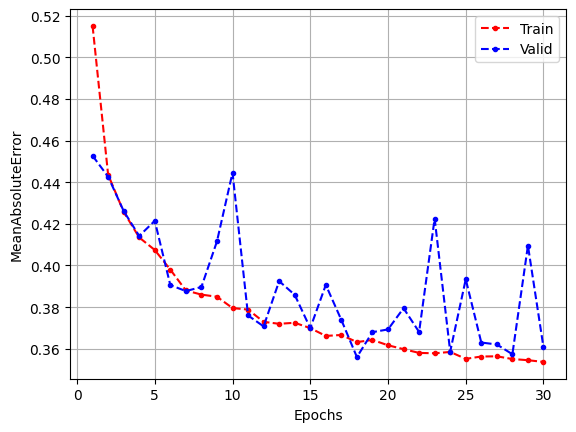

In [ ]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, weight_decay=0.001)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    clip_grad_norm=2
    )
plot_history(history, n_epochs, metric)

In [33]:
class Adam:
	def __init__(self, ad):
		self.ad = ad

a1 = Adam('Ali')
a2 = Adam('Lale')
isinstance(a1, Adam)

True

Epoch: 1/30, Loss: 1.73, Train Metric: 0.716, Valid Metric: 0.575
Epoch: 2/30, Loss: 0.48, Train Metric: 0.5, Valid Metric: 0.497
Epoch: 3/30, Loss: 0.401, Train Metric: 0.461, Valid Metric: 0.475
Epoch: 4/30, Loss: 0.379, Train Metric: 0.445, Valid Metric: 0.456
Epoch: 5/30, Loss: 0.365, Train Metric: 0.434, Valid Metric: 0.45
Epoch: 6/30, Loss: 0.356, Train Metric: 0.428, Valid Metric: 0.444
Epoch: 7/30, Loss: 0.351, Train Metric: 0.424, Valid Metric: 0.44
Epoch: 8/30, Loss: 0.344, Train Metric: 0.418, Valid Metric: 0.431
Epoch: 9/30, Loss: 0.341, Train Metric: 0.417, Valid Metric: 0.433
Epoch: 10/30, Loss: 0.337, Train Metric: 0.413, Valid Metric: 0.428
Epoch: 11/30, Loss: 0.335, Train Metric: 0.412, Valid Metric: 0.432
Epoch: 12/30, Loss: 0.332, Train Metric: 0.409, Valid Metric: 0.427
Epoch: 13/30, Loss: 0.329, Train Metric: 0.408, Valid Metric: 0.423
Epoch: 14/30, Loss: 0.327, Train Metric: 0.406, Valid Metric: 0.426
Epoch: 15/30, Loss: 0.326, Train Metric: 0.405, Valid Metric: 0

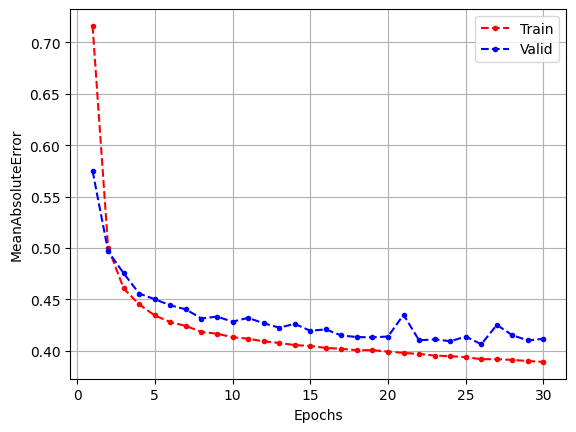

In [35]:
learning_rate = 0.01
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

def use_kaiming_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
        nn.init.zeros_(module.bias)

model.apply(use_kaiming_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    # clip_grad_norm=2
    )
plot_history(history, n_epochs, metric)

Epoch: 1/30, Loss: 0.719, Train Metric: 0.602, Valid Metric: 0.502
Epoch: 2/30, Loss: 0.478, Train Metric: 0.509, Valid Metric: 0.521
Epoch: 3/30, Loss: 0.453, Train Metric: 0.491, Valid Metric: 0.451
Epoch: 4/30, Loss: 0.428, Train Metric: 0.474, Valid Metric: 0.477
Epoch: 5/30, Loss: 0.428, Train Metric: 0.475, Valid Metric: 0.463
Epoch: 6/30, Loss: 0.413, Train Metric: 0.464, Valid Metric: 0.419
Epoch: 7/30, Loss: 0.408, Train Metric: 0.461, Valid Metric: 0.459
Epoch: 8/30, Loss: 0.404, Train Metric: 0.458, Valid Metric: 0.434
Epoch: 9/30, Loss: 0.398, Train Metric: 0.452, Valid Metric: 0.464
Epoch: 10/30, Loss: 0.404, Train Metric: 0.459, Valid Metric: 0.429
Epoch: 11/30, Loss: 0.401, Train Metric: 0.458, Valid Metric: 0.429
Epoch: 12/30, Loss: 0.396, Train Metric: 0.453, Valid Metric: 0.46
Epoch: 13/30, Loss: 0.4, Train Metric: 0.456, Valid Metric: 0.426
Epoch: 14/30, Loss: 0.404, Train Metric: 0.458, Valid Metric: 0.417
Epoch: 15/30, Loss: 0.391, Train Metric: 0.453, Valid Metric

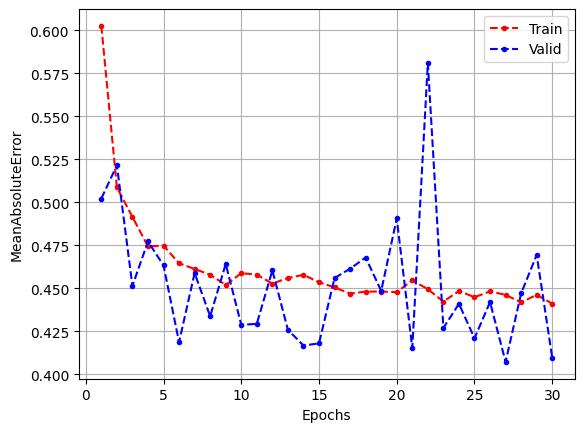

In [37]:
learning_rate = 0.1
n_epochs=30

# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.LeakyReLU(),
#     nn.BatchNorm1d(30),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.LeakyReLU(),
#     nn.BatchNorm1d(30),
# 	nn.Linear(in_features=50, out_features=1),
# ).to(device)

model = nn.Sequential(
    nn.BatchNorm1d(8),
	nn.Linear(in_features=8, out_features=30, bias=False), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(30),
	nn.Linear(in_features=30, out_features=50, bias=False), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(50),
	nn.Linear(in_features=50, out_features=1),
).to(device)

# def use_kaiming_init(module):
#     if isinstance(module, nn.Linear):
#         nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
#         nn.init.zeros_(module.bias)

# model.apply(use_kaiming_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    # clip_grad_norm=2
    )
plot_history(history, n_epochs, metric)

In [49]:
def train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs,
	scheduler, 
	warmup_scheduler, 
	clip_grad_norm=None
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		warmup_scheduler.step()

		#------------------------------------------------
		# 					Training 
		#------------------------------------------------
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			if clip_grad_norm is not None:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)

		avg_metric_train = metric.compute().item()

		#------------------------------------------------
		# 					Evaluation 
		#------------------------------------------------
		
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()

		#------------------------------------------------
		# 					Logging
		#------------------------------------------------
		history['train_metric'].append(avg_metric_train)
		history['loss'].append(avg_loss)
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)
		
		#------------------------------------------------
		# 					Scheduling
		#------------------------------------------------
		if epoch >= 5:
			scheduler.step()
			print(f'learning rate: {scheduler.get_last_lr()}')
		else:
			print(f'learning rate: {warmup_scheduler.get_last_lr()}')

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_9692\1261698931.py:19: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warmup_scheduler.step()


Epoch: 1/30, Loss: 0.703, Train Metric: 0.625, Valid Metric: 0.613
learning rate: [0.27999999999999997]
Epoch: 2/30, Loss: 0.617, Train Metric: 0.588, Valid Metric: 0.558
learning rate: [0.4599999999999999]
Epoch: 3/30, Loss: 0.627, Train Metric: 0.599, Valid Metric: 0.588
learning rate: [0.6399999999999999]
Epoch: 4/30, Loss: 0.735, Train Metric: 0.659, Valid Metric: 0.661
learning rate: [0.8199999999999998]
Epoch: 5/30, Loss: 0.871, Train Metric: 0.726, Valid Metric: 0.836
learning rate: [0.9999999999999998]
Epoch: 6/30, Loss: 0.852, Train Metric: 0.722, Valid Metric: 0.988
learning rate: [0.9499999999999997]
Epoch: 7/30, Loss: 0.824, Train Metric: 0.709, Valid Metric: 0.659
learning rate: [0.9024999999999997]
Epoch: 8/30, Loss: 0.794, Train Metric: 0.694, Valid Metric: 0.938
learning rate: [0.8573749999999997]
Epoch: 9/30, Loss: 0.72, Train Metric: 0.66, Valid Metric: 0.736
learning rate: [0.8145062499999997]
Epoch: 10/30, Loss: 0.681, Train Metric: 0.632, Valid Metric: 0.773
learni

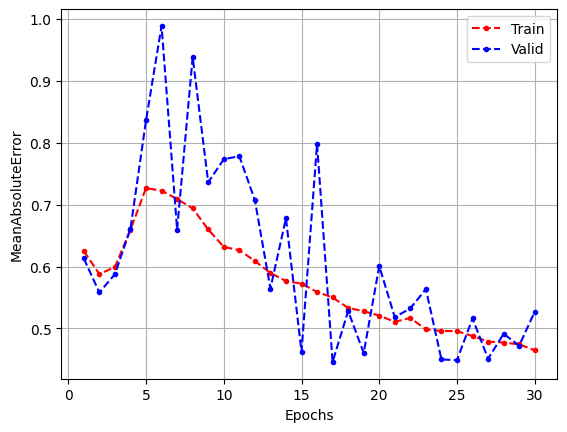

In [50]:
learning_rate = 0.1
n_epochs=30

# model = nn.Sequential(
# 	nn.Linear(in_features=8, out_features=30), 
# 	nn.LeakyReLU(),
#     nn.BatchNorm1d(30),
# 	nn.Linear(in_features=30, out_features=50), 
# 	nn.LeakyReLU(),
#     nn.BatchNorm1d(30),
# 	nn.Linear(in_features=50, out_features=1),
# ).to(device)

model = nn.Sequential(
    nn.BatchNorm1d(8),
	nn.Linear(in_features=8, out_features=30, bias=False), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(30),
	nn.Linear(in_features=30, out_features=50, bias=False), 
	nn.LeakyReLU(),
    nn.BatchNorm1d(50),
	nn.Linear(in_features=50, out_features=1),
).to(device)

# def use_kaiming_init(module):
#     if isinstance(module, nn.Linear):
#         nn.init.kaiming_uniform_(module.weight, nonlinearity='leaky_relu')
#         nn.init.zeros_(module.bias)

# model.apply(use_kaiming_init)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=1)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=5)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
    model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
    scheduler,
    warmup_scheduler, 
    clip_grad_norm=1
    )
plot_history(history, n_epochs, metric)